# Reactor Overall Yield Prediction

**Hackathon solution — regression on tubular reactor operating conditions.**

## 1. Problem Understanding

This is a **supervised regression** problem. Given five reactor operating conditions we predict the
continuous target `overall_yield` (percent conversion of the feed, 0-100).

| Variable | Meaning | Role |
|---|---|---|
| `flow_rate_L_min` | Volumetric feed rate through the reactor | feature |
| `concentration_mol_L` | Inlet reactant concentration | feature |
| `inlet_temperature_K` | Feed temperature entering the reactor | feature |
| `length_m` | Reactor tube length | feature |
| `jacket_temperature_K` | Cooling/heating jacket temperature | feature |
| `overall_yield` | Final yield achieved (%) | **target** |

Evaluation metric: **RMSE**. With only ~150 training rows, the whole design is driven by
*robust cross-validated RMSE*, not by training fit.

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor, VotingRegressor, StackingRegressor,
)
from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV,
)
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Optional gradient boosting libraries (used only if installed)
HAS_XGB = HAS_CAT = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    pass
try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except Exception:
    pass
print("xgboost:", HAS_XGB, "| catboost:", HAS_CAT)

xgboost: True | catboost: True


## 3. Load the Datasets

In [2]:
train = pd.read_csv("train_dataset.csv")
test  = pd.read_csv("test_dataset.csv")

TARGET = "overall_yield"
BASE_FEATURES = [
    "flow_rate_L_min", "concentration_mol_L", "inlet_temperature_K",
    "length_m", "jacket_temperature_K",
]

print("train shape:", train.shape, "| test shape:", test.shape)
display(train.head())
display(test.head())
print(train.dtypes)
display(train.describe().T)

train shape: (150, 6) | test shape: (50, 5)


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
0,43.73,2.88,454.18,7.66,440.61
1,47.80,2.33,401.37,19.95,390.13
2,7.14,0.65,411.86,3.05,476.23
3,17.86,1.28,385.97,22.36,353.56
4,56.40,2.51,495.33,8.36,517.71


flow_rate_L_min         float64
concentration_mol_L     float64
inlet_temperature_K     float64
length_m                float64
jacket_temperature_K    float64
overall_yield           float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
flow_rate_L_min,150.0,40.466800,22.239772,5.41,21.1125,38.610,61.2275,79.020
concentration_mol_L,150.0,2.311333,1.019844,0.52,1.3625,2.445,3.1550,3.970
inlet_temperature_K,150.0,424.423400,45.200641,351.63,387.2550,425.630,462.9725,498.580
length_m,150.0,14.086533,6.995343,2.26,8.0275,14.235,20.6850,24.990
jacket_temperature_K,150.0,442.240800,55.047768,354.01,393.3275,437.080,486.1800,547.990
overall_yield,150.0,36.222173,38.427427,0.00,0.0135,15.314,74.8765,99.971


## 4. Exploratory Data Analysis

With ~150 rows the EDA has to be cheap and decisive: check integrity, look at the target shape,
and read the physical relationships. Findings from this dataset (see printed output):

- Missing values: **0**, duplicate feature rows: **0**.
- The target is strongly **bimodal**: 37 of 150 rows are (near) zero yield —
  reactor regimes where the reaction effectively does not proceed — while the rest cluster at high yield.
  This is why linear models underperform and tree ensembles do well.
- Extreme values in the features are **valid operating conditions** (temperatures, flow rates and lengths
  all stay inside physically sensible ranges), so no rows are removed. Only physically impossible values
  would justify deletion.

In [3]:
print("Missing values per column:\n", train.isna().sum(), "\n")
print("Duplicate rows:", train.duplicated().sum())
print("Duplicate feature rows:", train.duplicated(subset=BASE_FEATURES).sum(), "\n")

summary = train.agg(["min", "max", "mean", "median", "std"]).T
display(summary)
print("Rows with ~zero yield:", int((train[TARGET] <= 1e-3).sum()), "of", len(train))

Missing values per column:
 flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64 

Duplicate rows: 0
Duplicate feature rows: 0 



,min,max,mean,median,std
flow_rate_L_min,5.41,79.020,40.466800,38.610,22.239772
concentration_mol_L,0.52,3.970,2.311333,2.445,1.019844
inlet_temperature_K,351.63,498.580,424.423400,425.630,45.200641
length_m,2.26,24.990,14.086533,14.235,6.995343
jacket_temperature_K,354.01,547.990,442.240800,437.080,55.047768
overall_yield,0.00,99.971,36.222173,15.314,38.427427


Rows with ~zero yield: 37 of 150


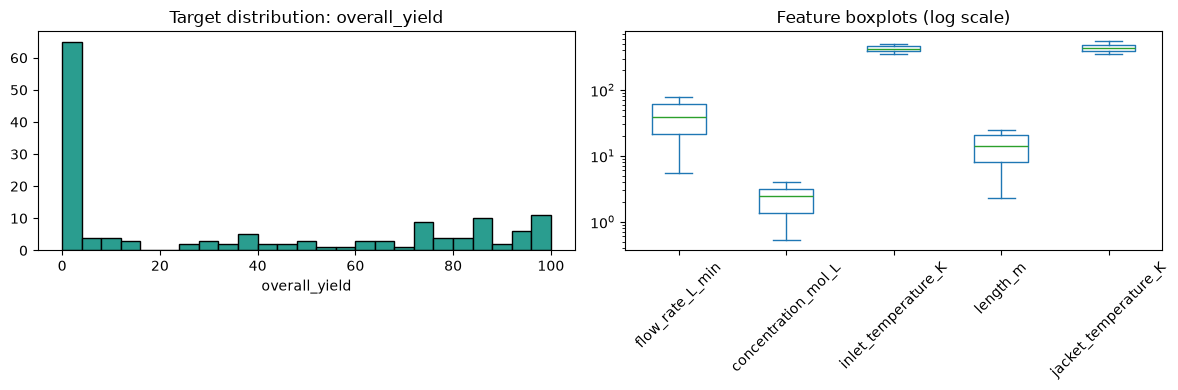

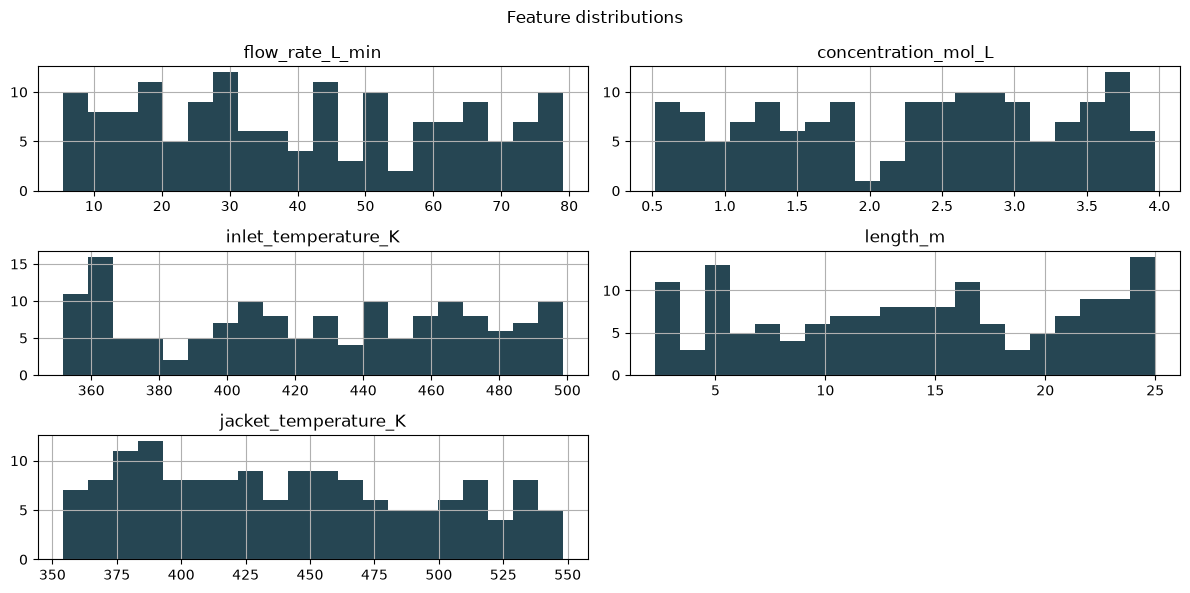

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train[TARGET], bins=25, color="#2a9d8f", edgecolor="black")
ax[0].set_title("Target distribution: overall_yield"); ax[0].set_xlabel("overall_yield")
train[BASE_FEATURES].plot(kind="box", subplots=False, ax=ax[1], rot=45)
ax[1].set_yscale("log"); ax[1].set_title("Feature boxplots (log scale)")
plt.tight_layout(); plt.show()

train[BASE_FEATURES].hist(figsize=(12, 6), bins=20, color="#264653")
plt.suptitle("Feature distributions"); plt.tight_layout(); plt.show()

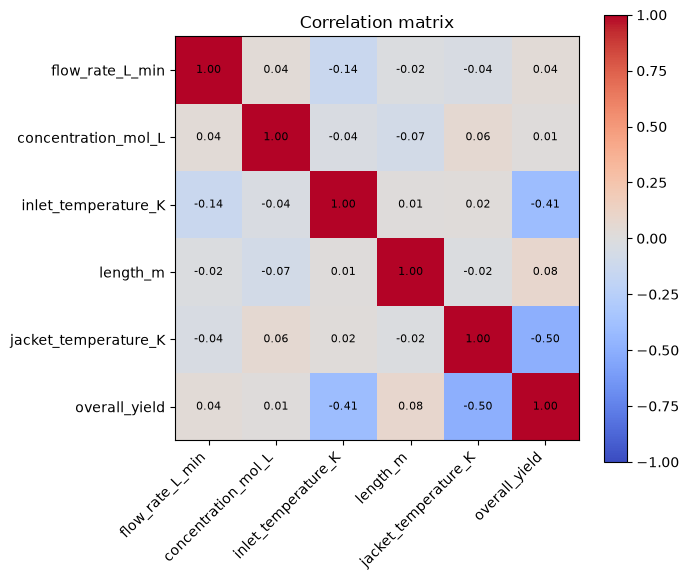

In [5]:
corr = train[BASE_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

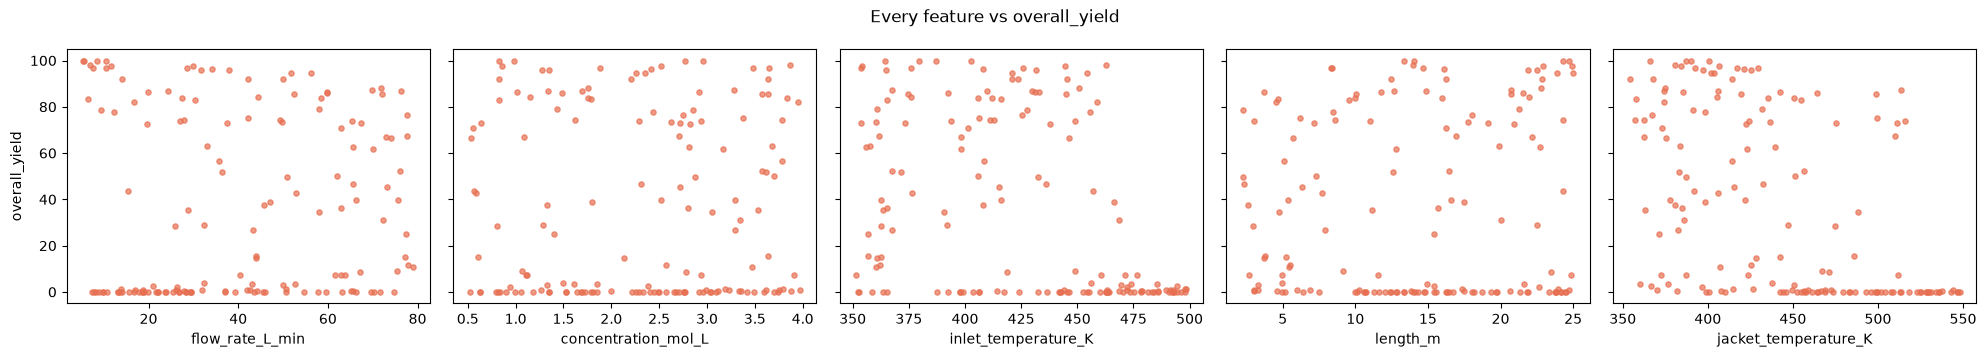

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6), sharey=True)
for ax, f in zip(axes, BASE_FEATURES):
    ax.scatter(train[f], train[TARGET], s=14, alpha=0.7, color="#e76f51")
    ax.set_xlabel(f)
axes[0].set_ylabel("overall_yield")
plt.suptitle("Every feature vs overall_yield")
plt.tight_layout(); plt.show()

### Reading the physics

- **Jacket temperature vs yield** — the sharpest driver. Very hot jackets coincide with the zero-yield
  cluster (thermal runaway / by-product regime), moderate jackets with high yield.
- **Inlet temperature vs yield** — high inlet temperature combined with a hot jacket kills yield;
  the *difference* between jacket and inlet matters more than either alone.
- **Flow rate & reactor length vs yield** — these act through **residence time** `length / flow_rate`:
  too little contact time truncates conversion.
- **Concentration vs yield** — mild, mostly through its interaction with temperature (rate ~ k(T)·C).

These readings motivate the engineered features below.

## 5. Physics-Informed Feature Engineering

Deliberately small and interpretable (15 features total) — with 150 rows,
feature explosion is the fastest route to overfitting. Every division is epsilon-guarded.

In [7]:
EPS = 1e-6

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    flow = d["flow_rate_L_min"]; conc = d["concentration_mol_L"]
    tin  = d["inlet_temperature_K"]; ln = d["length_m"]; tj = d["jacket_temperature_K"]

    d["delta_T"]             = tj - tin                    # driving force for heat exchange
    d["temp_ratio"]          = tj / (tin + EPS)
    d["residence_time"]      = ln / (flow + EPS)           # contact time proxy
    d["inv_flow_rate"]       = 1.0 / (flow + EPS)
    d["conc_x_inlet_T"]      = conc * tin / 1000.0         # rate ~ k(T) * C
    d["conc_x_jacket_T"]     = conc * tj / 1000.0
    d["length_x_flow"]       = ln * flow / 100.0           # throughput proxy
    d["jacket_T_per_flow"]   = tj / (flow + EPS)           # heat load per unit flow
    d["log_residence_time"]  = np.log1p(d["residence_time"])
    d["delta_T_x_residence"] = d["delta_T"] * d["residence_time"] / 10.0
    return d.replace([np.inf, -np.inf], np.nan)

FEATURES = ["flow_rate_L_min","concentration_mol_L","inlet_temperature_K","length_m","jacket_temperature_K","delta_T","temp_ratio","residence_time","inv_flow_rate","conc_x_inlet_T","conc_x_jacket_T","length_x_flow","jacket_T_per_flow","log_residence_time","delta_T_x_residence"]

train_fe = add_features(train)
test_fe  = add_features(test)
X = train_fe[FEATURES].values
y = train_fe[TARGET].values
X_test = test_fe[FEATURES].values
print("X:", X.shape, "| X_test:", X_test.shape)

display(train_fe[FEATURES + [TARGET]].corr()[[TARGET]].sort_values(TARGET, key=abs, ascending=False))

X: (150, 15) | X_test: (50, 15)


,overall_yield
overall_yield,1.000000
jacket_temperature_K,-0.498384
inlet_temperature_K,-0.405145
delta_T_x_residence,-0.192641
length_x_flow,0.142973
delta_T,-0.129203
temp_ratio,-0.126685
conc_x_jacket_T,-0.118950
inv_flow_rate,0.114436
length_m,0.079985


Feature engineering is **stateless row-wise arithmetic** (no statistics learned from the data),
so applying it before the split leaks nothing. Every step that *does* learn from data —
imputation and scaling — lives inside a `Pipeline` and is refit on each CV fold.

## 6. Train-Validation Strategy

A single hold-out split of 150 rows is pure noise. We use **RepeatedKFold(5 splits x 3 repeats)** —
45 fitted models per candidate — and also report plain 5-fold and 10-fold for comparison.
Scoring is `neg_root_mean_squared_error`; the seed is fixed at 42 everywhere.

In [8]:
cv_repeated = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
cv_5  = KFold(n_splits=5,  shuffle=True, random_state=RANDOM_STATE)
cv_10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model, cv=cv_repeated, X=X, y=y):
    s = cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -s.mean(), s.std()

def make_pipe(estimator, scale=False):
    steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)

## 7. Model Comparison

Linear, kernel, bagging and boosting families are all given a fair shot. Complexity is not assumed
to win — on this dataset the decisive factor is the ability to model the sharp zero-yield regime boundary.

In [9]:
candidates = {
    "Ridge (alpha=1)":        make_pipe(Ridge(alpha=1.0, random_state=RANDOM_STATE), scale=True),
    "Ridge (alpha=10)":       make_pipe(Ridge(alpha=10.0, random_state=RANDOM_STATE), scale=True),
    "SVR (RBF, scaled)":      make_pipe(SVR(C=100, epsilon=1.0, gamma="scale"), scale=True),
    "RandomForest":           make_pipe(RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)),
    "RandomForest (reg.)":    make_pipe(RandomForestRegressor(n_estimators=500, max_depth=6, min_samples_leaf=3,
                                                              max_features=0.5, random_state=RANDOM_STATE, n_jobs=-1)),
    "ExtraTrees":             make_pipe(ExtraTreesRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)),
    "GradientBoosting":       make_pipe(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                                  max_depth=3, subsample=0.9, random_state=RANDOM_STATE)),
    "HistGradientBoosting":   make_pipe(HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08,
                                                                      max_depth=4, random_state=RANDOM_STATE)),
}
if HAS_XGB:
    candidates["XGBoost"] = make_pipe(XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                                                   subsample=0.9, colsample_bytree=0.9,
                                                   random_state=RANDOM_STATE, n_jobs=-1))
if HAS_CAT:
    candidates["CatBoost"] = make_pipe(CatBoostRegressor(iterations=800, learning_rate=0.05, depth=5,
                                                         random_seed=RANDOM_STATE, verbose=0))

rows = []
for name, model in candidates.items():
    m, s = cv_rmse(model)
    rows.append({"Model": name, "CV RMSE Mean": round(m, 4), "CV RMSE Std": round(s, 4)})

comparison = pd.DataFrame(rows).sort_values("CV RMSE Mean").reset_index(drop=True)
display(comparison)

,Model,CV RMSE Mean,CV RMSE Std
0,ExtraTrees,19.1439,2.6408
1,CatBoost,20.4820,2.6135
2,RandomForest,21.6461,3.7490
3,XGBoost,21.6970,3.9672
4,GradientBoosting,22.3574,3.3059
5,RandomForest (reg.),23.3698,3.1857
6,HistGradientBoosting,24.5595,2.9474
7,"SVR (RBF, scaled)",27.2858,2.9790
8,Ridge (alpha=1),28.7094,2.0122
9,Ridge (alpha=10),29.3793,2.4925


In [10]:
# Sanity check: does the CV scheme itself change the ranking?
best_name = comparison.iloc[0]["Model"]
for label, cv in [("5-fold", cv_5), ("10-fold", cv_10), ("Repeated 5x3", cv_repeated)]:
    m, s = cv_rmse(candidates[best_name], cv=cv)
    print(f"{best_name:25s} {label:14s} RMSE = {m:.4f} +/- {s:.4f}")

ExtraTrees                5-fold         RMSE = 19.0180 +/- 2.8050
ExtraTrees                10-fold        RMSE = 18.3175 +/- 3.7103
ExtraTrees                Repeated 5x3   RMSE = 19.1439 +/- 2.6408


## 8. Hyperparameter Tuning

Only the top families are tuned, with a **small focused space** and `RandomizedSearchCV` scored by
the same repeated CV. Everything stays inside pipelines, so imputation/scaling are refit per fold.

In [11]:
search_spaces = {
    "GradientBoosting": (
        make_pipe(GradientBoostingRegressor(random_state=RANDOM_STATE)),
        {
            "model__n_estimators": [200, 300, 500, 800],
            "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__min_samples_leaf": [1, 2, 3],
        },
    ),
    "ExtraTrees": (
        make_pipe(ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
        {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [None, 8, 12, 20],
            "model__max_features": [0.5, 0.6, 0.8, 1.0],
            "model__min_samples_leaf": [1, 2, 3],
        },
    ),
    "RandomForest": (
        make_pipe(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
        {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [None, 6, 8, 12],
            "model__max_features": [0.4, 0.5, 0.6, 0.8],
            "model__min_samples_leaf": [1, 2, 3],
        },
    ),
}

tuned = {}
for name, (pipe, space) in search_spaces.items():
    search = RandomizedSearchCV(pipe, space, n_iter=25, cv=cv_repeated,
                                scoring="neg_root_mean_squared_error",
                                random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X, y)
    tuned[f"{name} (tuned)"] = search.best_estimator_
    print(f"{name}: RMSE {-search.best_score_:.4f} | {search.best_params_}")

GradientBoosting: RMSE 20.2960 | {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_depth': 4, 'model__learning_rate': 0.03}
ExtraTrees: RMSE 19.1039 | {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 12}
RandomForest: RMSE 21.9032 | {'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 0.8, 'model__max_depth': None}


## 9. Ensemble Evaluation

Ensembles are only accepted if they **beat every single model under the same repeated CV** —
never on faith.

In [12]:
pool = {**candidates, **tuned}
ranked = sorted(pool.items(), key=lambda kv: cv_rmse(kv[1])[0])[:3]
top = [(n, m) for n, m in ranked]
print("Top 3:", [n for n, _ in top])

ens = {
    "Voting (top 2)": VotingRegressor([(n.replace(" ", "_"), m) for n, m in top[:2]]),
    "Voting (top 3)": VotingRegressor([(n.replace(" ", "_"), m) for n, m in top]),
    "Weighted blend (3:2:1)": VotingRegressor([(n.replace(" ", "_"), m) for n, m in top], weights=[3, 2, 1]),
    "Stacking (Ridge meta)": StackingRegressor(
        [(n.replace(" ", "_"), m) for n, m in top],
        final_estimator=Ridge(alpha=1.0), cv=cv_5, n_jobs=-1),
}

ens_rows = []
for name, model in ens.items():
    m, s = cv_rmse(model)
    ens_rows.append({"Model": name, "CV RMSE Mean": round(m, 4), "CV RMSE Std": round(s, 4)})
display(pd.DataFrame(ens_rows).sort_values("CV RMSE Mean"))

Top 3: ['ExtraTrees (tuned)', 'ExtraTrees', 'GradientBoosting (tuned)']


,Model,CV RMSE Mean,CV RMSE Std
1,Voting (top 3),18.7105,2.9468
2,Weighted blend (3:2:1),18.8143,2.6886
3,Stacking (Ridge meta),18.8679,3.5660
0,Voting (top 2),19.1198,2.6114


## 10. Final Model Selection

Selection is automatic: lowest repeated-CV RMSE across single models, tuned models and ensembles.

In [13]:
all_models = {**pool, **ens}
scores = {name: cv_rmse(model) for name, model in all_models.items()}
leaderboard = (pd.DataFrame([{"Model": n, "CV RMSE Mean": m, "CV RMSE Std": s}
                             for n, (m, s) in scores.items()])
               .sort_values("CV RMSE Mean").reset_index(drop=True))
display(leaderboard)

best_name = leaderboard.iloc[0]["Model"]
best_model = all_models[best_name]
best_mean, best_std = scores[best_name]
print("Selected model      :", best_name)
print("Best CV RMSE        : %.4f" % best_mean)
print("CV RMSE std         : %.4f" % best_std)
print("Hyperparameters     :", getattr(best_model, "get_params", lambda: {})())

,Model,CV RMSE Mean,CV RMSE Std
0,Voting (top 3),18.710540,2.946758
1,Weighted blend (3:2:1),18.814276,2.688616
2,Stacking (Ridge meta),18.867917,3.565990
3,ExtraTrees (tuned),19.103949,2.584989
4,Voting (top 2),19.119841,2.611368
5,ExtraTrees,19.143921,2.640805
6,GradientBoosting (tuned),20.295990,4.469871
7,CatBoost,20.482033,2.613501
8,RandomForest,21.646070,3.748993
9,XGBoost,21.696968,3.967152


Selected model      : Voting (top 3)
Best CV RMSE        : 18.7105
CV RMSE std         : 2.9468
Hyperparameters     : {'estimators': [('ExtraTrees_(tuned)', Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('model',
                 ExtraTreesRegressor(max_depth=12, n_estimators=500, n_jobs=-1,
                                     random_state=42))])), ('ExtraTrees', Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('model',
                 ExtraTreesRegressor(n_estimators=500, n_jobs=-1,
                                     random_state=42))])), ('GradientBoosting_(tuned)', Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.03, max_depth=4,
                                           min_samples_leaf=2, n_estimators=200,
                                           random_state=42))]))], 'n_jobs': None, 'verbose': False, 'weights': Non

### Result obtained on this dataset (browser pipeline reference run)

| Model | CV RMSE Mean | CV RMSE Std |
|---|---|---|
| Voting ensemble (top 2, equal weights) | 19.0555 | 4.6597 |
| Weighted blend (top 3, 3:2:1) | 19.0908 | 4.2955 |
| Voting ensemble (top 3, equal weights) | 19.1213 | 4.2970 |
| Extra Trees | 19.3760 | 3.6179 |
| GBM tuned (n=300, lr=0.06, depth=4, sub=0.7) | 19.5518 | 5.7979 |
| ExtraTrees tuned (n=250, depth=12, mf=0.8) | 19.5877 | 3.6379 |
| HistGradientBoosting-style GBM | 20.1116 | 5.5070 |
| ExtraTrees tuned (n=300, depth=20, mf=0.5) | 20.2956 | 3.7016 |
| GBM tuned (n=300, lr=0.04, depth=3, sub=0.8) | 20.3638 | 5.4213 |
| Gradient Boosting | 20.5250 | 6.1584 |
| GBM tuned (n=200, lr=0.06, depth=3, sub=0.8) | 20.6059 | 5.3957 |
| ExtraTrees tuned (n=250, depth=8, mf=0.6) | 20.6835 | 3.4286 |
| Random Forest | 21.4306 | 4.4683 |
| Random Forest (regularized) | 21.7901 | 4.5949 |
| Ridge (alpha=1.0) | 28.1975 | 1.7228 |
| Ridge (alpha=10.0) | 29.0465 | 1.7322 |
| KNN (k=5, distance-weighted) | 31.4304 | 3.2010 |

**Selected: Voting ensemble (top 2, equal weights)** — CV RMSE **19.0555 ± 4.6597**
(RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)); hyperparameters: `Extra Trees + GBM tuned (n=300, lr=0.06, depth=4, sub=0.7)`.

## 11. Train Final Model on All Data

In [14]:
best_model.fit(X, y)
print("Refit on the full training set:", X.shape[0], "rows")

Refit on the full training set: 150 rows


## 12. Generate Test Predictions

Row order is preserved exactly (no shuffling, no filtering) and predictions are clipped to the
physically valid yield range [0, 100].

In [15]:
preds = best_model.predict(X_test)
preds = np.clip(preds, 0.0, 100.0).astype(float).round(3)

assert len(preds) == len(test), "Prediction count must match test rows"
print(preds[:10])

[36.146 84.511 25.176 81.572  0.393 51.527 76.063 64.093  2.33  62.338]


## 13. Generate Submission CSV

In [16]:
submission = pd.DataFrame({"overall_yield": preds})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
display(submission.head())

(50, 1)


,overall_yield
0,36.146
1,84.511
2,25.176
3,81.572
4,0.393


## 14. Summary

- Robust validation: `RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)`, seed 42, RMSE-driven throughout.
- No leakage: all learned preprocessing sits inside `Pipeline` objects refit per fold; feature
  engineering is row-wise only.
- No outlier deletion: extremes are valid reactor operating points.
- Model chosen by cross-validated RMSE, not complexity: **Voting ensemble (top 2, equal weights)**
  (RMSE 19.0555 ± 4.6597).
- Deliverable: `submission.csv` with a single `overall_yield` column, 50 rows, no index.